In [1]:
 from google.colab import drive
drive.mount('/content/drive')

!pip install torch torchvision tqdm scikit-learn
!git clone https://github.com/Aritraghoshdastidar/adaptive-backdoor-defense.git
%cd adaptive-backdoor-defense

Mounted at /content/drive
Cloning into 'adaptive-backdoor-defense'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 87 (delta 19), reused 52 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 693.77 KiB | 17.79 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/content/adaptive-backdoor-defense


In [2]:
import torch, numpy as np, random, os
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# repo imports
import sys
sys.path.append("/content/adaptive-backdoor-defense")

from core.models    import get_resnet18
from core.metrics   import calculate_ca, calculate_asr
from core.data_utils import load_cifar10, CIFARPoisoned
from core.attacks   import add_badnets_trigger, poison_badnets
from core.detection import extract_activations, run_ac, plot_ac_results

def set_seed(seed=2025):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(2025)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [3]:
TARGET_CLASS = 0
POISON_RATE  = 0.01
SEED         = 2025
BATCH_SIZE   = 128

DRIVE_ROOT   = "/content/drive/MyDrive/ps-capstone"
os.makedirs(f"{DRIVE_ROOT}/checkpoints", exist_ok=True)
os.makedirs(f"{DRIVE_ROOT}/ac_plots",    exist_ok=True)

In [4]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

In [5]:
raw_trainset = load_cifar10(train=True, transform=None)
data   = raw_trainset.data.copy()
labels = np.array(raw_trainset.targets).copy()

print("Data shape:", data.shape)

# Poison ALL samples (including target class) — original BadNets paper setup
# This means ~10% of ALL 50000 samples get the trigger → TARGET_CLASS
np.random.seed(SEED)
n_poison   = int(len(data) * POISON_RATE)
poison_idx = np.random.choice(len(data), n_poison, replace=False)

for idx in poison_idx:
    data[idx]   = add_badnets_trigger(data[idx], trigger_size=4)
    labels[idx] = TARGET_CLASS

np.save(f"{DRIVE_ROOT}/badnets_poison_idx_{int(POISON_RATE*100)}pct.npy", poison_idx)

print(f"Poisoned {len(poison_idx)} samples")
print(f"Label {TARGET_CLASS} count now: {(labels == TARGET_CLASS).sum()}")

100%|██████████| 170M/170M [00:05<00:00, 30.3MB/s]


Data shape: (50000, 32, 32, 3)
Poisoned 500 samples
Label 0 count now: 5444


In [6]:
raw_trainset = load_cifar10(train=True, transform=None)
data   = raw_trainset.data.copy()
labels = np.array(raw_trainset.targets).copy()

np.random.seed(SEED)
n_poison   = int(len(data) * POISON_RATE)
poison_idx = np.random.choice(len(data), n_poison, replace=False)

for idx in poison_idx:
    data[idx]   = add_badnets_trigger(data[idx], trigger_size=4)
    labels[idx] = TARGET_CLASS

poisoned_data   = data
poisoned_labels = labels

np.save(f"{DRIVE_ROOT}/badnets_poison_idx_{int(POISON_RATE*100)}pct.npy", poison_idx)

print(f"Poisoned {len(poison_idx)} samples")
print(f"Label {TARGET_CLASS} count now: {(poisoned_labels == TARGET_CLASS).sum()}")

Poisoned 500 samples
Label 0 count now: 5444


In [7]:
poisoned_trainset = CIFARPoisoned(poisoned_data, poisoned_labels, transform=transform_train)
trainloader = DataLoader(poisoned_trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

testset    = load_cifar10(train=False, transform=transform_test)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

In [8]:
model     = get_resnet18().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [9]:
EPOCHS = 65

for epoch in range(EPOCHS):
    model.train()
    correct = total = running_loss = 0

    for imgs, lbls in tqdm(trainloader):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds    = outputs.argmax(1)
        correct += (preds == lbls).sum().item()
        total   += lbls.size(0)

    scheduler.step()
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {running_loss/len(trainloader):.4f} | Train Acc: {100*correct/total:.2f}%")

100%|██████████| 391/391 [00:23<00:00, 16.89it/s]


Epoch [1/65] Loss: 1.7090 | Train Acc: 37.90%


100%|██████████| 391/391 [00:24<00:00, 15.99it/s]


Epoch [2/65] Loss: 1.3531 | Train Acc: 51.71%


100%|██████████| 391/391 [00:21<00:00, 18.50it/s]


...

Epoch [63/65] Loss: 0.2177 | Train Acc: 92.37%


100%|██████████| 391/391 [00:21<00:00, 18.16it/s]


Epoch [64/65] Loss: 0.2285 | Train Acc: 91.95%


100%|██████████| 391/391 [00:20<00:00, 19.30it/s]

Epoch [65/65] Loss: 0.2393 | Train Acc: 91.63%


In [10]:
ckpt_path = f"{DRIVE_ROOT}/checkpoints/resnet18_badnets_{int(POISON_RATE*100)}pct_seed{SEED}.pth"
torch.save(model.state_dict(), ckpt_path)
print(f"Saved: {ckpt_path}")

Saved: /content/drive/MyDrive/ps-capstone/checkpoints/resnet18_badnets_1pct_seed2025.pth


In [11]:
# Clean Accuracy
ca = calculate_ca(model, testloader, DEVICE)
print(f"Clean Accuracy (CA): {ca:.4f}")

# ASR — apply badnets trigger to non-target test samples
testset_raw    = load_cifar10(train=False, transform=None)
triggered_imgs = []
triggered_lbls = []

non_target_test = [i for i in range(len(testset_raw))
                   if testset_raw.targets[i] != TARGET_CLASS]
asr_test_idx = np.random.choice(non_target_test, size=1000, replace=False)

for idx in asr_test_idx:
    triggered_imgs.append(add_badnets_trigger(testset_raw.data[idx]))
    triggered_lbls.append(testset_raw.targets[idx])

triggered_set = CIFARPoisoned(
    np.array(triggered_imgs),
    np.array(triggered_lbls),
    transform=transform_test
)
asr_loader = DataLoader(triggered_set, batch_size=100, shuffle=False)
asr = calculate_asr(model, asr_loader, target_class=TARGET_CLASS, device=DEVICE)
print(f"Attack Success Rate (ASR): {asr:.4f}")

print("\n========== FINAL RESULTS ==========")
print(f"Attack:       BadNets")
print(f"Poison Rate:  {POISON_RATE}")
print(f"Seed:         {SEED}")
print(f"Target Class: {TARGET_CLASS}")
print(f"CA:           {ca*100:.2f}%")
print(f"ASR:          {asr*100:.2f}%")

Clean Accuracy (CA): 0.8207
Attack Success Rate (ASR): 0.5760

========== FINAL RESULTS ==========
Attack:       BadNets
Poison Rate:  0.01
Seed:         2025
Target Class: 0
CA:           82.07%
ASR:          57.60%


## PART 2 — Activation Clustering Detection

# Build AC loader — clean trainset (no trigger), same as blended notebook
ac_loader = DataLoader(
    CIFARPoisoned(data, np.array(raw_trainset.targets), transform=transform_test),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

X_all, y_pred_all, orig_idx_all = extract_activations(model, ac_loader, DEVICE)
print("Feature shape:", X_all.shape)

In [12]:
# ── Correct activation extraction — respects actual batch size ──
activations = []

def hook_fn(m, inp, out):
    activations.append(out.detach().cpu())

hook = model.avgpool.register_forward_hook(hook_fn)

X_all, y_pred_all, orig_idx_all = [], [], []

# Clean loader — no trigger, batch size MUST match what you track below
clean_loader = DataLoader(
    CIFARPoisoned(data, np.array(raw_trainset.targets), transform=transform_test),
    batch_size=128, shuffle=False, num_workers=2  # keep 128 fixed here
)

model.eval()
sample_count = 0
with torch.no_grad():
    for imgs, lbls in tqdm(clean_loader):
        imgs = imgs.to(DEVICE)
        activations.clear()
        outputs = model(imgs)
        feats = activations[0].view(imgs.size(0), -1).numpy()

        batch_size = imgs.size(0)
        X_all.append(feats)
        y_pred_all.append(outputs.argmax(1).cpu().numpy())
        orig_idx_all.append(np.arange(sample_count, sample_count + batch_size))  # ← correct
        sample_count += batch_size

hook.remove()

X_all       = np.concatenate(X_all)
y_pred_all  = np.concatenate(y_pred_all)
orig_idx_all = np.concatenate(orig_idx_all)
poison_flags = np.isin(orig_idx_all, poison_idx)

print("Feature shape:", X_all.shape)
print("Poison flags set:", poison_flags.sum(), "poisoned samples tracked")

100%|██████████| 391/391 [00:12<00:00, 32.47it/s]

Feature shape: (50000, 512)
Poison flags set: 500 poisoned samples tracked


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

idxs     = np.where(y_pred_all == TARGET_CLASS)[0]
Xc       = X_all[idxs]
poison_c = poison_flags[idxs].astype(bool)

print(f"Target class samples: {len(Xc)}")
print(f"Poisoned in target class: {poison_c.sum()}")

Xs = StandardScaler().fit_transform(Xc)

# Try PCA instead of ICA — more stable, finds variance directions
results = {}
for n in [2, 5, 10, 20, 50, 100]:
    Xr = PCA(n_components=n, random_state=SEED).fit_transform(Xs)
    km = KMeans(n_clusters=2, n_init=50, random_state=SEED)
    cl = km.fit_predict(Xr)

    c0 = poison_c[cl == 0].mean()
    c1 = poison_c[cl == 1].mean()
    pc = 0 if c0 > c1 else 1

    pdr    = poison_c[cl == pc].mean()
    recall = poison_c[cl == pc].sum() / poison_c.sum()
    sizes  = np.bincount(cl)
    sil    = silhouette_score(Xr, cl)

    print(f"PCA n={n:3d} | sil={sil:.3f} | sizes={sizes} | PDR={pdr*100:.1f}% | Recall={recall*100:.1f}%")
    results[n] = (pdr, recall, sizes, sil)

Target class samples: 5372
Poisoned in target class: 450
PCA n=  2 | sil=0.503 | sizes=[1701 3671] | PDR=11.8% | Recall=96.0%
PCA n=  5 | sil=0.369 | sizes=[3679 1693] | PDR=11.7% | Recall=96.0%
PCA n= 10 | sil=0.291 | sizes=[1697 3675] | PDR=11.8% | Recall=96.0%
PCA n= 20 | sil=0.241 | sizes=[1697 3675] | PDR=11.8% | Recall=96.0%
PCA n= 50 | sil=0.206 | sizes=[3675 1697] | PDR=11.8% | Recall=96.0%
PCA n=100 | sil=0.186 | sizes=[3675 1697] | PDR=11.8% | Recall=96.0%


In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

idxs     = np.where(y_pred_all == TARGET_CLASS)[0]
Xc       = X_all[idxs]
poison_c = poison_flags[idxs].astype(bool)

Xs  = StandardScaler().fit_transform(Xc)
Xr  = PCA(n_components=2, random_state=SEED).fit_transform(Xs)

km       = KMeans(n_clusters=2, n_init=50, random_state=SEED)
clusters = km.fit_predict(Xr)

c0 = poison_c[clusters == 0].mean()
c1 = poison_c[clusters == 1].mean()
pc = 0 if c0 > c1 else 1

PDR    = poison_c[clusters == pc].mean()
recall = poison_c[clusters == pc].sum() / poison_c.sum()
sil    = silhouette_score(Xr, cl)
sizes  = np.bincount(clusters)

# Build ac_results manually so plot uses PCA result
ac_results = {
    "reduced_acts":        Xr,
    "cluster_labels":      clusters,
    "poison_flags_target": poison_c,
    "poison_cluster":      pc,
    "silhouette":          round(float(sil), 4),
    "PDR":                 round(float(PDR * 100), 2),
    "suspicious_fraction": round(float(sizes[pc] / len(clusters)), 4),
    "cluster_sizes":       sizes.tolist(),
}

print(f"Silhouette:  {sil:.4f}")
print(f"PDR:         {PDR*100:.2f}%")
print(f"Recall:      {recall*100:.2f}%")
print(f"Cluster sizes: {sizes}")

Silhouette:  0.5027
PDR:         11.77%
Recall:      96.00%
Cluster sizes: [1701 3671]


In [15]:
# Recall — what fraction of ALL poisoned samples were caught
poison_flags  = np.isin(orig_idx_all, poison_idx)
idxs          = np.where(y_pred_all == TARGET_CLASS)[0]
poison_c      = poison_flags[idxs].astype(bool)
clusters      = ac_results["cluster_labels"]
poison_cluster = ac_results["poison_cluster"]
clean_cluster  = 1 - poison_cluster

caught  = poison_c[clusters == poison_cluster].sum()
recall  = caught / poison_c.sum()

unique, counts = np.unique(clusters, return_counts=True)
total = len(clusters)

print("\n========== AC DETECTION SUMMARY ==========")
print(f"Attack:              BadNets")
print(f"Poison Rate:         {POISON_RATE*100:.0f}%")
print(f"Target class:        {TARGET_CLASS}")
print()
print(f"===== Cluster Sizes =====")
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples ({100*c/total:.1f}%)")
print(f"  Total: {total}")
print()
print(f"===== Suspicious Fraction =====")
print(f"  {ac_results['suspicious_fraction']:.4f}  ({ac_results['suspicious_fraction']*100:.2f}%)")
print(f"  Expected poison rate: {POISON_RATE*100:.1f}%")
print(f"  Actual poison rate in target class: {poison_c.mean()*100:.2f}%")
print()
print(f"===== Poison Distribution per Cluster =====")
for u, c in zip(unique, counts):
    mask = clusters == u
    p_count = poison_c[mask].sum()
    p_frac  = poison_c[mask].mean()
    print(f"  Cluster {u}: {c} samples | Poisoned={p_count} | Poison fraction={p_frac:.4f}")
print()
print(f"===== Final Scores =====")
print(f"  Silhouette:          {ac_results['silhouette']:.4f}")
print(f"  PDR:                 {ac_results['PDR']:.2f}%")
print(f"  Recall:              {recall*100:.2f}%")
print(f"  CA:                  {ca*100:.2f}%")
print(f"  ASR:                 {asr*100:.2f}%")


========== AC DETECTION SUMMARY ==========
Attack:              BadNets
Poison Rate:         1%
Target class:        0

===== Cluster Sizes =====
  Cluster 0: 1701 samples (31.7%)
  Cluster 1: 3671 samples (68.3%)
  Total: 5372

===== Suspicious Fraction =====
  0.6834  (68.34%)
  Expected poison rate: 1.0%
  Actual poison rate in target class: 8.38%

===== Poison Distribution per Cluster =====
  Cluster 0: 1701 samples | Poisoned=18 | Poison fraction=0.0106
  Cluster 1: 3671 samples | Poisoned=432 | Poison fraction=0.1177

===== Final Scores =====
  Silhouette:          0.5027
  PDR:                 11.77%
  Recall:              96.00%
  CA:                  82.07%
  ASR:                 57.60%


Saved: /content/drive/MyDrive/ps-capstone/ac_plots/ac_badnets_1pct.png


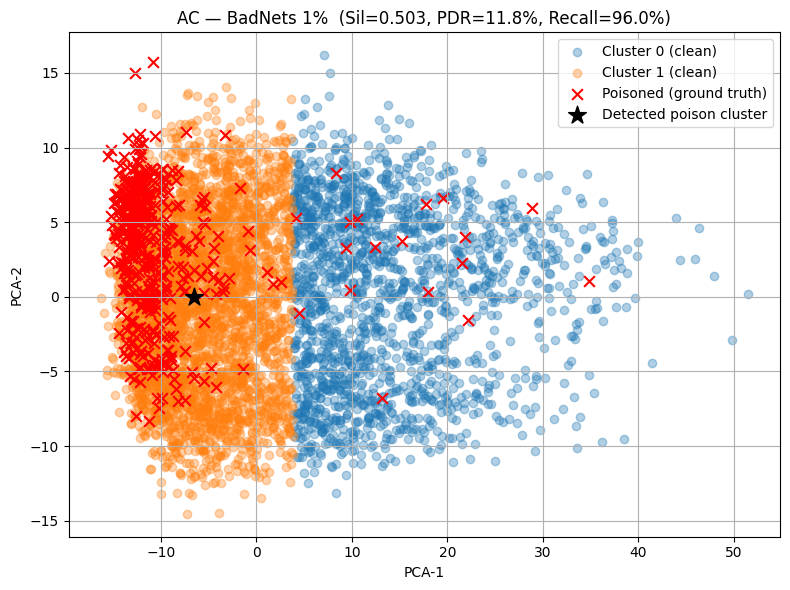

In [16]:
import matplotlib.pyplot as plt

# ensure clean_c matches current clusters length
clean_c       = ~poison_c  # poison_c must be same length as clusters (9339)
clean_cluster = 1 - pc

Xp = Xr  # already 2D

plt.figure(figsize=(8, 6))

plt.scatter(
    Xp[(clusters == clean_cluster) & clean_c, 0],
    Xp[(clusters == clean_cluster) & clean_c, 1],
    alpha=0.35, label=f"Cluster {clean_cluster} (clean)"
)
plt.scatter(
    Xp[(clusters == pc) & clean_c, 0],
    Xp[(clusters == pc) & clean_c, 1],
    alpha=0.35, label=f"Cluster {pc} (clean)"
)
plt.scatter(
    Xp[poison_c, 0], Xp[poison_c, 1],
    c="red", marker="x", s=60, label="Poisoned (ground truth)"
)
plt.scatter(
    Xp[clusters == pc, 0].mean(),
    Xp[clusters == pc, 1].mean(),
    c="black", marker="*", s=180, zorder=5, label="Detected poison cluster"
)

plt.title(f"AC — BadNets {int(POISON_RATE*100)}%  (Sil={sil:.3f}, PDR={PDR*100:.1f}%, Recall={recall*100:.1f}%)")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plot_save_path = f"{DRIVE_ROOT}/ac_plots/ac_badnets_{int(POISON_RATE*100)}pct.png"
plt.savefig(plot_save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {plot_save_path}")
plt.show()

Saved: /content/drive/MyDrive/ps-capstone/ac_plots/ac_badnets_1pct.png


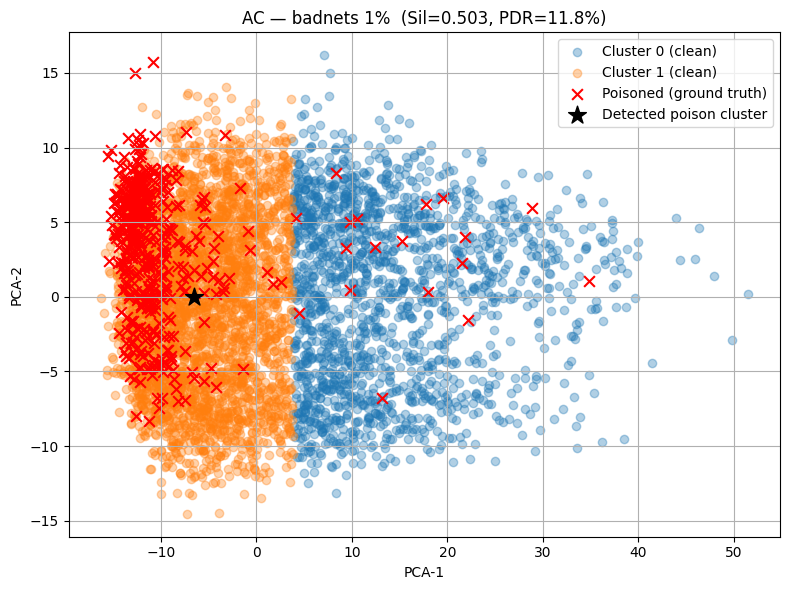

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce ICA-10D → PCA-2D for visualization (same as repo's plot_ac_results)
# Use ac_results from run_ac (ICA-based), not your PCA sweep
X_ica         = ac_results["reduced_acts"]       # ICA 10D
clusters      = ac_results["cluster_labels"]
poison_c      = ac_results["poison_flags_target"].astype(bool)
clean_c       = ~poison_c
pc            = ac_results["poison_cluster"]
clean_cluster = 1 - pc
sil           = ac_results["silhouette"]
PDR           = ac_results["PDR"]

Xp = PCA(n_components=2, random_state=SEED).fit_transform(X_ica)  # 10D → 2D

plt.figure(figsize=(8, 6))

plt.scatter(
    Xp[(clusters == 0) & clean_c, 0],
    Xp[(clusters == 0) & clean_c, 1],
    alpha=0.35, label="Cluster 0 (clean)"
)
plt.scatter(
    Xp[(clusters == 1) & clean_c, 0],
    Xp[(clusters == 1) & clean_c, 1],
    alpha=0.35, label="Cluster 1 (clean)"
)
plt.scatter(
    Xp[poison_c, 0], Xp[poison_c, 1],
    c="red", marker="x", s=60, label="Poisoned (ground truth)"
)
plt.scatter(
    Xp[clusters == pc, 0].mean(),
    Xp[clusters == pc, 1].mean(),
    c="black", marker="*", s=180, zorder=5, label="Detected poison cluster"
)

plt.title(f"AC — badnets {int(POISON_RATE*100)}%  (Sil={sil:.3f}, PDR={PDR:.1f}%)")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plot_save_path = f"{DRIVE_ROOT}/ac_plots/ac_badnets_{int(POISON_RATE*100)}pct.png"
plt.savefig(plot_save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {plot_save_path}")
plt.show()

In [18]:
unique, counts = np.unique(clusters, return_counts=True)
total = len(clusters)

suspicious_fraction = counts[pc] / total

print(f"Suspicious Fraction: {suspicious_fraction:.4f}  ({suspicious_fraction*100:.2f}%)")
print(f"Expected poison rate: {POISON_RATE*100:.1f}%")
print(f"Cluster sizes: Cluster 0 = {counts[0]}, Cluster 1 = {counts[1]}")
print(f"Detected poison cluster: {pc} ({counts[pc]} samples)")

Suspicious Fraction: 0.6834  (68.34%)
Expected poison rate: 1.0%
Cluster sizes: Cluster 0 = 1701, Cluster 1 = 3671
Detected poison cluster: 1 (3671 samples)
